In [1]:
Create 3 visualizations from a spatial and time-series dataset of your choice.
Describe your dataset including where it came from and the features it contains. 
Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

RESPONSE:

1.This map shows how COVID-19 spread across Asia over time. In January 2020, most cases were in China. 
The bubbles grow larger and change color to show higher case numbers over time.

2.This line chart shows how the prices of different metals changed over the years. Some metals, like gold, 
go up over time, especially during events like the 2008 financial crisis or the COVID-19 pandemic. Other metals show more ups and downs.

3.This map shows reported Bigfoot sightings in the U.S. over 10 years. Most sightings happen in the Pacific Northwest, 
like Washington and Oregon. The animation shows the different sightings over time and the classifications of those sightings. 


SyntaxError: invalid syntax (2611393491.py, line 1)

In [35]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('CV_LatLon_21Jan_12Mar.csv')

df.columns


Index(['Unnamed: 0', 'state', 'country', 'lat', 'lon', 'date', 'confirmed',
       'recovered', 'death'],
      dtype='object')

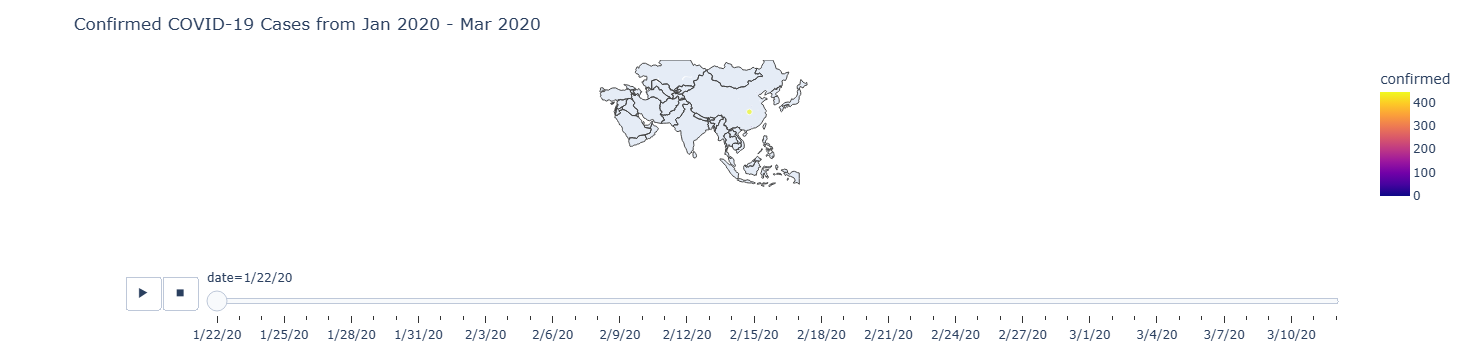

In [37]:
import plotly.io as pio

# switch to a compatible renderer
pio.renderers.default = "plotly_mimetype" 
fig = px.scatter_geo(df,
                     lat='lat',
                     lon='lon',
                     color='confirmed',
                     size='confirmed',
                     animation_frame='date',
                     size_max=50,
                     scope='asia',
                     labels={'lat': 'Latitude', 'lon': 'Longitude'})

fig.update_layout(title='Confirmed COVID-19 Cases in Asia from Jan 2020 - Mar 2020')
fig.show()



In [39]:
gold_df = pd.read_csv('all_commodities_data.csv')
gold_df.head()

,ticker,commodity,date,open,high,low,close,volume
0,GC=F,Gold,2000-08-30,273.899994,273.899994,273.899994,273.899994,0
1,GC=F,Gold,2000-08-31,274.799988,278.299988,274.799988,278.299988,0
2,GC=F,Gold,2000-09-01,277.000000,277.000000,277.000000,277.000000,0
3,GC=F,Gold,2000-09-05,275.799988,275.799988,275.799988,275.799988,2
4,GC=F,Gold,2000-09-06,274.200012,274.200012,274.200012,274.200012,0


In [40]:
gold_df.columns

Index(['ticker', 'commodity', 'date', 'open', 'high', 'low', 'close',
       'volume'],
      dtype='object')

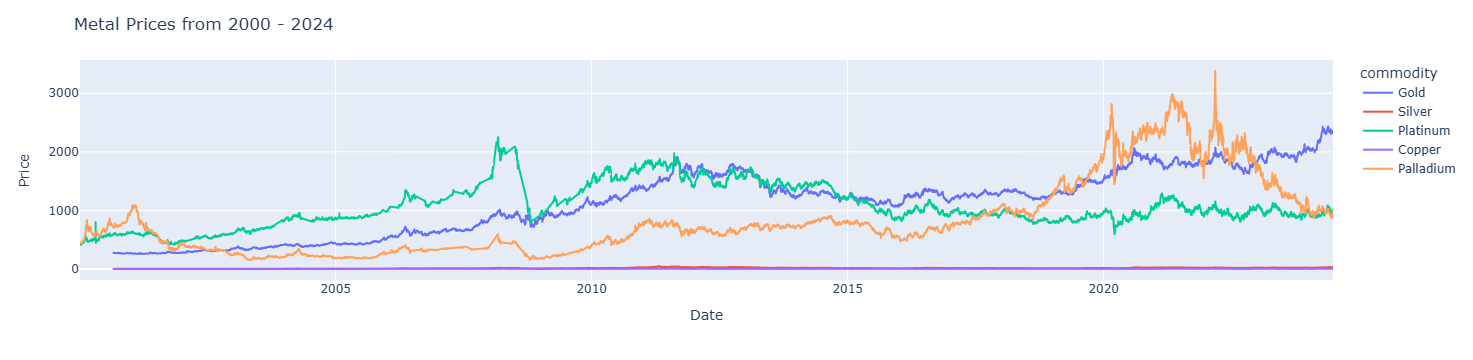

In [44]:
fig = px.line(gold_df, x= 'date', y='high', color='commodity',
             hover_data=['open','low','close'],
             hover_name='commodity')

fig.update_layout(title='Metal Prices from 2000 - 2024',
           xaxis_title ='Date',
           yaxis_title= 'Price')

fig.show()
              

In [20]:
bf_df = pd.read_csv('bfro-report-locations.csv')
bf_df.head()

,number,title,classification,timestamp,latitude,longitude
0,637,Report 637: Campers' encounter just after dark...,Class A,2000-06-16T12:00:00Z,61.5000,-142.9000
1,2917,Report 2917: Family observes large biped from car,Class A,1995-05-15T12:00:00Z,55.1872,-132.7982
2,7963,Report 7963: Sasquatch walks past window of ho...,Class A,2004-02-09T12:00:00Z,55.2035,-132.8202
3,9317,"Report 9317: Driver on Alcan Highway has noon,...",Class A,2004-06-18T12:00:00Z,62.9375,-141.5667
4,13038,Report 13038: Snowmobiler has encounter in dee...,Class A,2004-02-15T12:00:00Z,61.0595,-149.7853


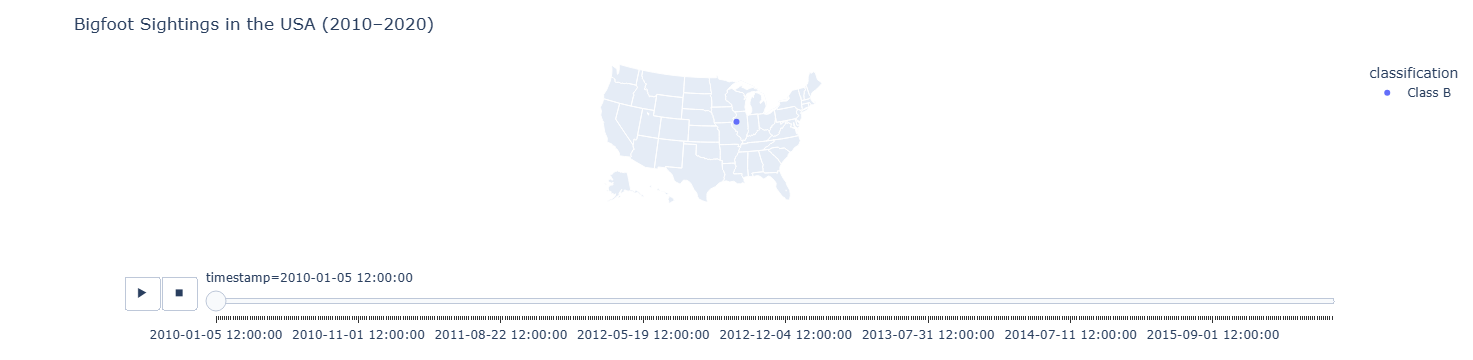

In [29]:
pio.renderers.default = "plotly_mimetype"    # use notebook renderer in JupyterLab

bf_df["timestamp"] = pd.to_datetime(bf_df["timestamp"], errors="coerce")

# filter years 2010–2020
bf_df = bf_df[(bf_df["timestamp"].dt.year >= 2010) & (bf_df["timestamp"].dt.year <= 2020)]



# plot
fig = px.scatter_geo(
    bf_df,
    lat="latitude",
    lon="longitude",
    color="classification",
    animation_frame="timestamp",   
    scope="usa",
    size_max=30
)

fig.update_layout(title="Bigfoot Sightings in the USA (2010–2020)")
fig.show()

